# Pendulum Integrators, Damping, and Nonlinearity

Euler, Euler–Cromer, and midpoint Runge–Kutta integration for harmonic, driven, damped, and nonlinear pendulums.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


length of pendulum L [m]: 1
initial angle theta0 [rad]: 0
initial angular velocity omega0 [rad/s]: 1
Omega0 = sqrt(g/L) = 3.130495 rad/s, period T = 2.007090 s
dt [s]: 0.01
number of time steps: 1000


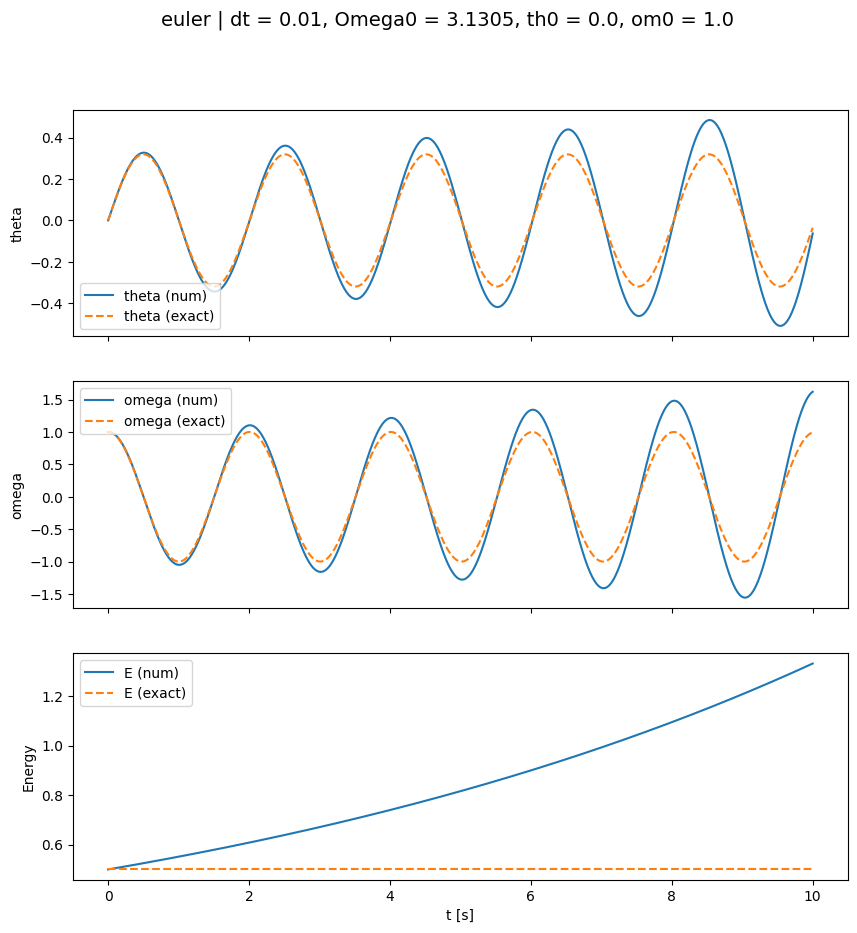

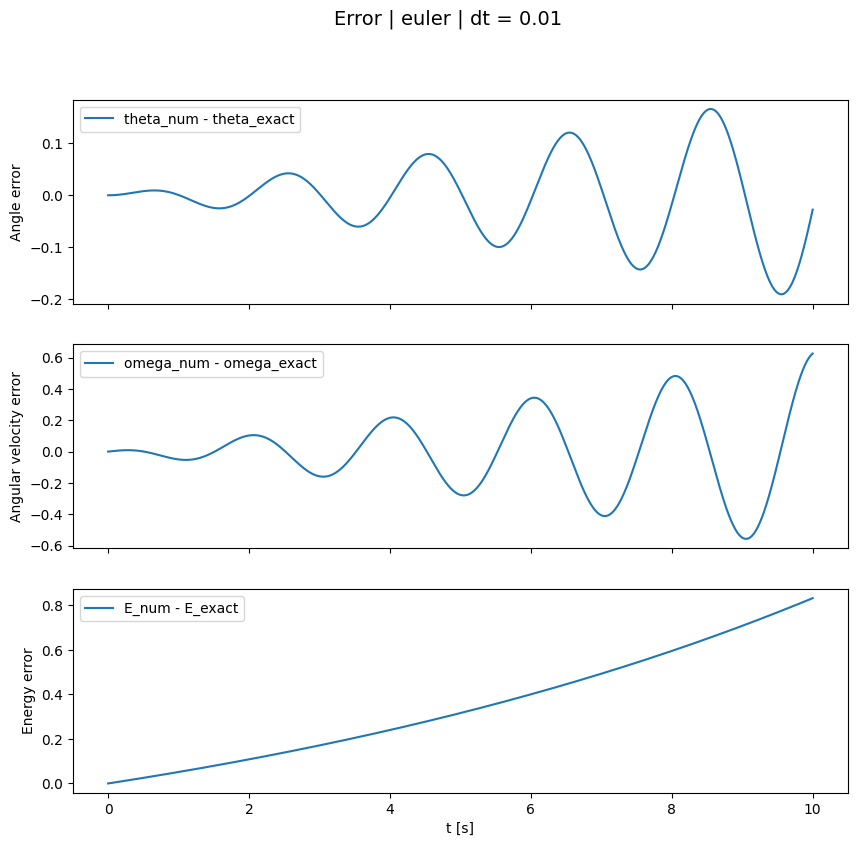

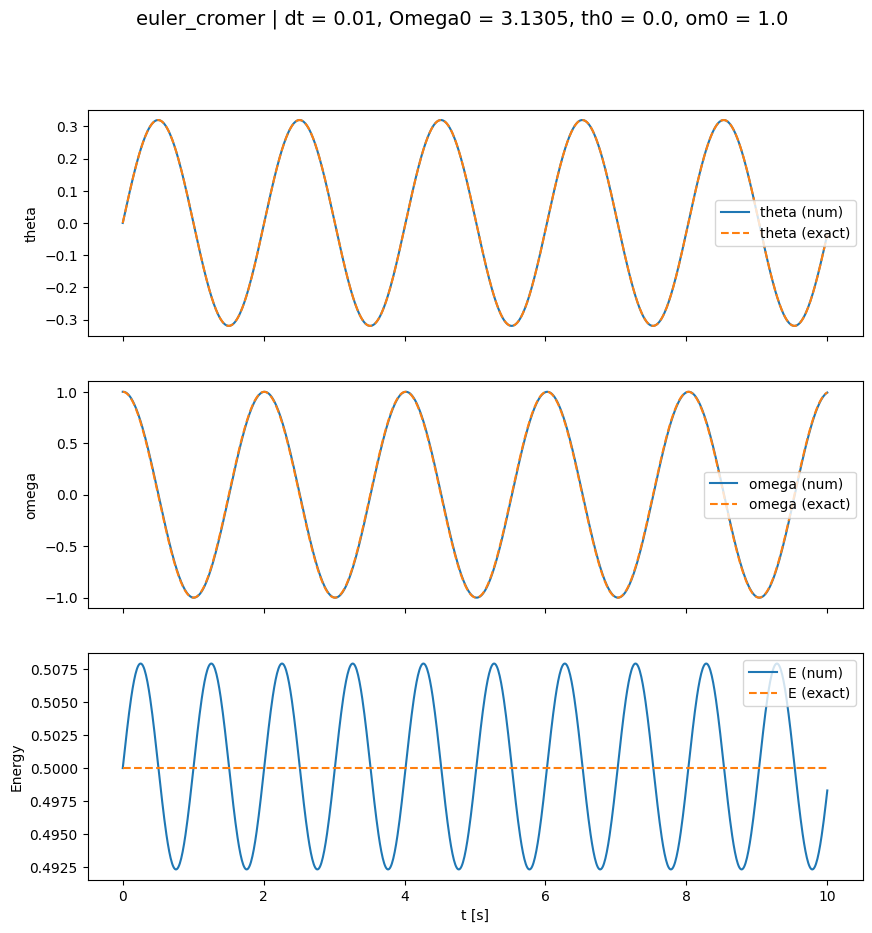

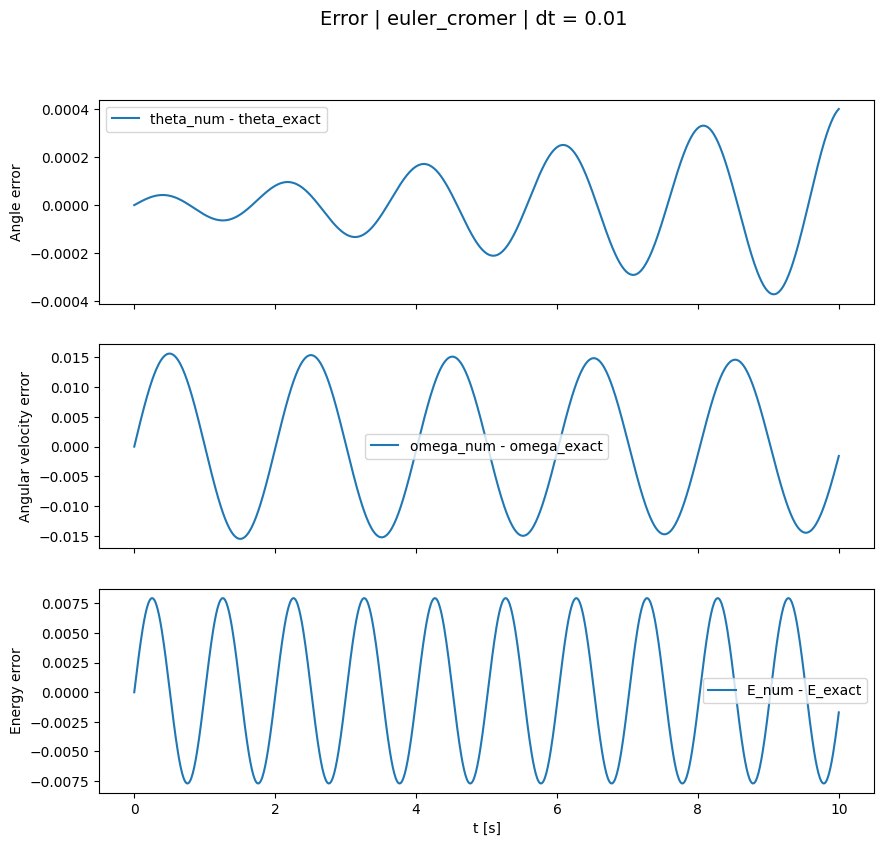

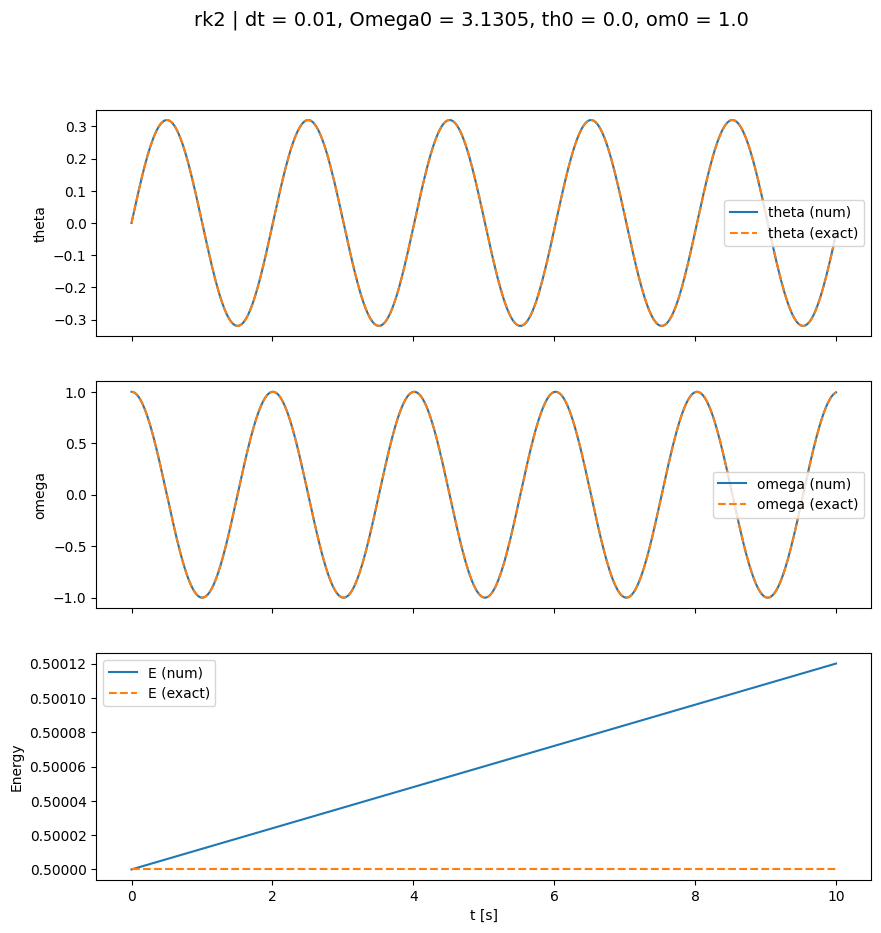

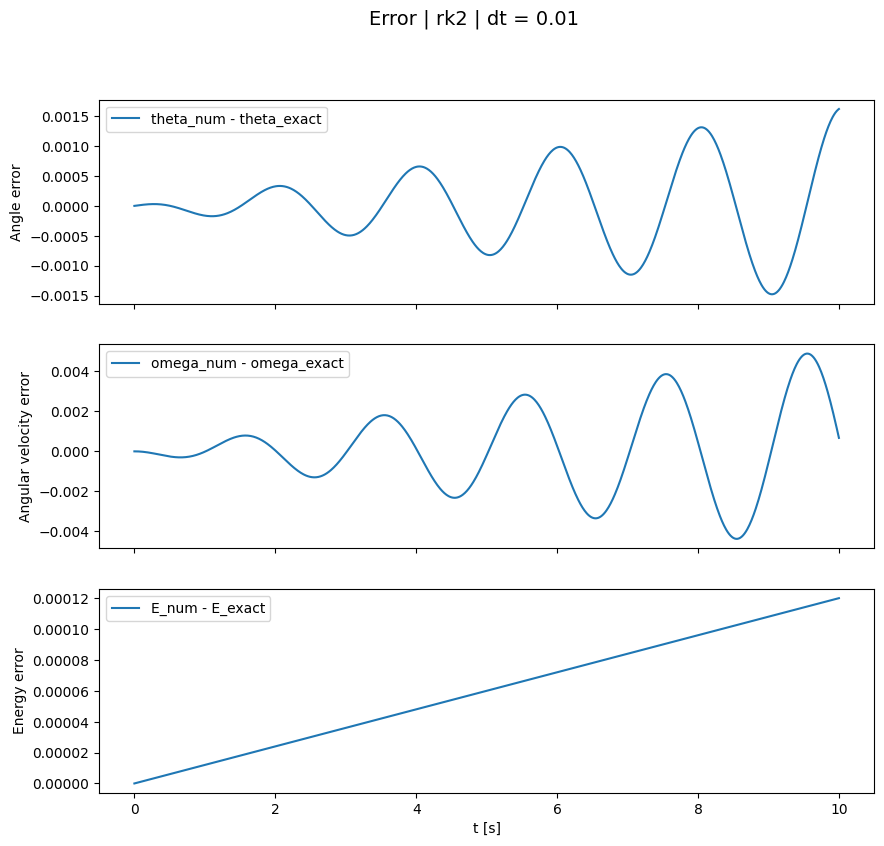

In [ ]:
# Lab 3, Part 1
# Undamped pendulum motion, in small-angle approximation
#
# ODE system:   1) dtheta/dt = omega
#               2) domega/dt = -Omega0^2 * theta
#
#     where Omega0^2 = g / L
#
# Solved numerically via Euler's method, Euler Cromer, and RK2

import math;
import numpy as np;
import matplotlib.pyplot as plt;

# Exact solution (small-angle harmonic oscillator)
# theta(t) = th0 cos(O t) + (om0/O) sin(O t)
# omega(t) = -th0 O sin(O t) + om0 cos(O t)
def exact_solution(th0, om0, Omega0, t):
    ct = np.cos(Omega0 * t);
    st = np.sin(Omega0 * t);
    theta = th0 * ct + (om0 / Omega0) * st;
    omega = -th0 * Omega0 * st + om0 * ct;
    return theta, omega;

# Integrator
# ODE: dtheta/dt = omega
#      domega/dt = -Omega0^2 * theta
def step_euler(theta, omega, Omega0, dt):
    theta_new = theta + omega * dt;
    omega_new = omega - (Omega0**2) * theta * dt;
    return theta_new, omega_new;

# Updating omega first, then theta using the NEW omega
def step_euler_cromer(theta, omega, Omega0, dt):
    omega_new = omega - (Omega0**2) * theta * dt;
    theta_new = theta + omega_new * dt;
    return theta_new, omega_new;

# Midpoint RK2: y_{n+1} = y_n + dt * f(t_n + dt/2, y_n + (dt/2) f(t_n, y_n)). Here f does not explicitly depend on t
def step_rk2_midpoint(theta, omega, Omega0, dt):
    def f(th, om):
        dth = om;
        dom = -(Omega0**2) * th;
        return dth, dom;

    k1_th, k1_om = f(theta, omega);
    th_mid = theta + 0.5 * dt * k1_th;
    om_mid = omega + 0.5 * dt * k1_om;
    k2_th, k2_om = f(th_mid, om_mid);

    theta_new = theta + dt * k2_th;
    omega_new = omega + dt * k2_om;
    return theta_new, omega_new;

# Trajectory caluclator
def compute_trajectory(method, th0, om0, Omega0, dt, nsteps):
    theta = np.zeros(nsteps + 1);
    omega = np.zeros(nsteps + 1);
    theta[0] = th0;
    omega[0] = om0;

    stepper = {"euler": step_euler, "euler_cromer": step_euler_cromer, "rk2": step_rk2_midpoint}[method];

    th, om = th0, om0;
    for i in range(nsteps):
        th, om = stepper(th, om, Omega0, dt);
        theta[i + 1] = th;
        omega[i + 1] = om;

    return theta, omega;

# Plotting function
def run_and_plot(th0, om0, Omega0, dt, nsteps, method, show_exact=True):
    t = np.arange(nsteps + 1) * dt;

    # Energy up to a constant scale factor. This is the standard quadratic invariant equation/relationship thing.
    th_num, om_num = compute_trajectory(method, th0, om0, Omega0, dt, nsteps);
    E_num = 0.5 * (om_ex**2 + (Omega0**2) * th_ex**2);
    th_ex, om_ex = exact_solution(th0, om0, Omega0, t);
    E_ex = 0.5 * (om_ex**2 + (Omega0**2) * th_ex**2);  # constant (numerically)

    # Use SIGNED errors and include omega error to match handout style
    err_th = th_num - th_ex;
    err_om = om_num - om_ex;
    err_E  = E_num - E_ex;

    # Results Graph Set: trajectories + energy
    fig1, ax = plt.subplots(3, sharex = True, figsize = (10, 10));
    fig1.suptitle(f"{method} | dt = {dt}, Omega0 = {Omega0:.4f}, th0 = {th0}, om0 = {om0}", fontsize = 14);

    ax[0].plot(t, th_num, label = "theta (num)");
    if show_exact:
        ax[0].plot(t, th_ex, "--", label = "theta (exact)");
    ax[0].set_ylabel("theta");
    ax[0].legend();

    ax[1].plot(t, om_num, label = "omega (num)");
    if show_exact:
        ax[1].plot(t, om_ex, "--", label = "omega (exact)");
    ax[1].set_ylabel("omega");
    ax[1].legend();

    ax[2].plot(t, E_num, label = "E (num)");
    ax[2].plot(t, E_ex, "--", label = "E (exact)");
    ax[2].set_ylabel("Energy");
    ax[2].set_xlabel("t [s]");
    ax[2].legend();

    # Errors Graph Set: errors (theta, omega, energy) - SIGNED
    fig2, ax2 = plt.subplots(3, sharex = True, figsize = (10, 9));
    fig2.suptitle(f"Error | {method} | dt = {dt}", fontsize = 14);

    ax2[0].plot(t, err_th, label = "theta_num - theta_exact");
    ax2[0].set_ylabel("Angle error");
    ax2[0].legend();

    ax2[1].plot(t, err_om, label = "omega_num - omega_exact");
    ax2[1].set_ylabel("Angular velocity error");
    ax2[1].legend();

    ax2[2].plot(t, err_E, label = "E_num - E_exact");
    ax2[2].set_ylabel("Energy error");
    ax2[2].set_xlabel("t [s]");
    ax2[2].legend();

    plt.show();

def main():
    # Inputs - same as starter
    L   = float(input("length of pendulum L [m]: "));
    th0 = float(input("initial angle theta0 [rad]: "));
    om0 = float(input("initial angular velocity omega0 [rad/s]: "));

    g = 9.8;
    Omega0 = math.sqrt(g / L);
    print(f"Omega0 = sqrt(g/L) = {Omega0:.6f} rad/s, period T = {2*math.pi/Omega0:.6f} s");

    dt = float(input("dt [s]: "));
    nsteps = int(input("number of time steps: "));

    # Runnign each method for the same dt
    for method in ["euler", "euler_cromer", "rk2"]:
        run_and_plot(th0, om0, Omega0, dt, nsteps, method, show_exact = True);

if __name__ == "__main__":
    main();

#EOF



Using L = 9.8 m, g = 9.8 m/s^2 => Omega0 = sqrt(g/L) = 1.000000 rad/s


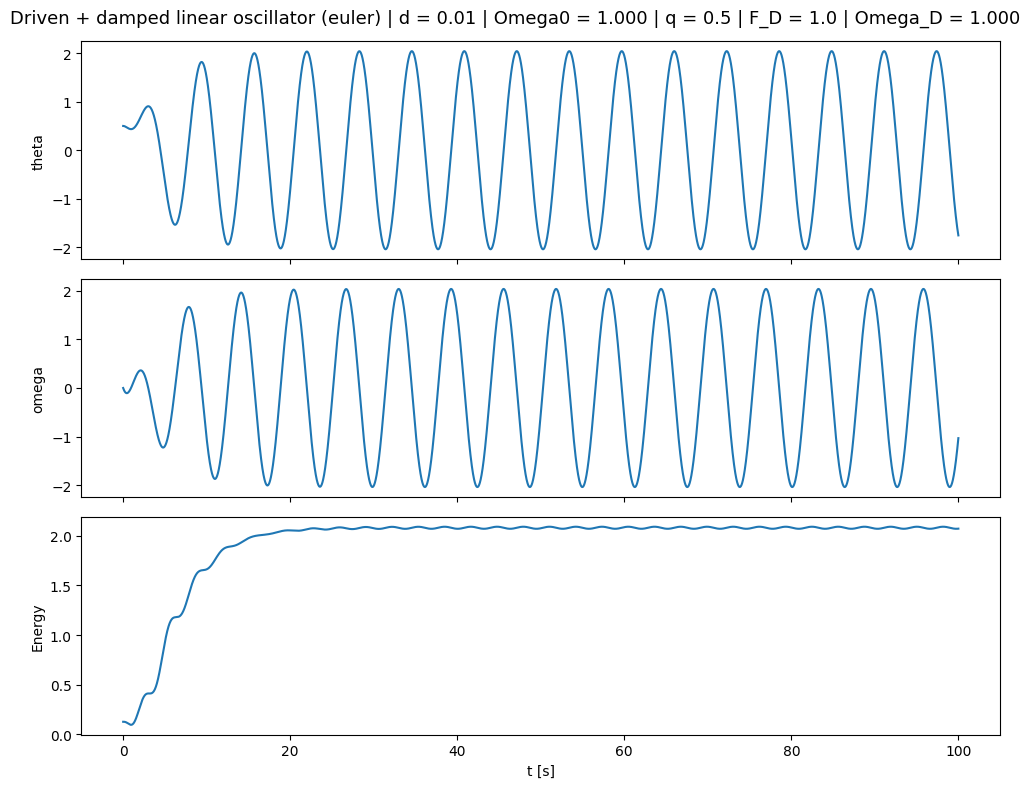

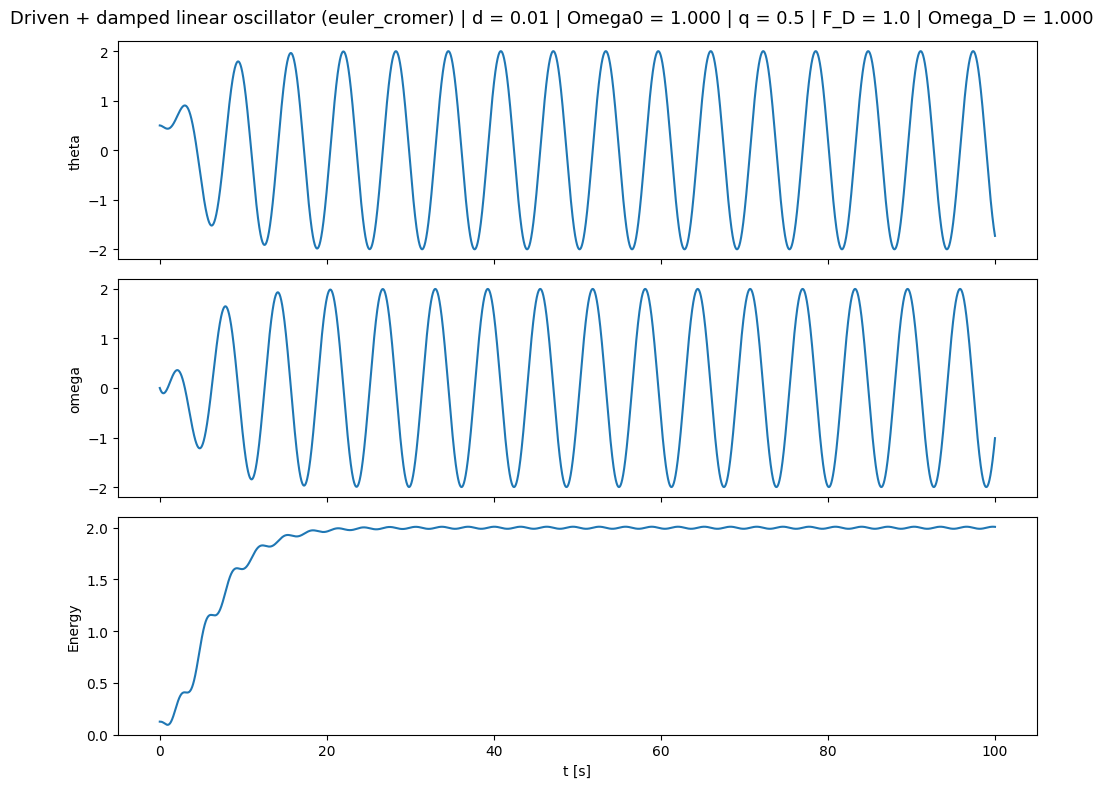

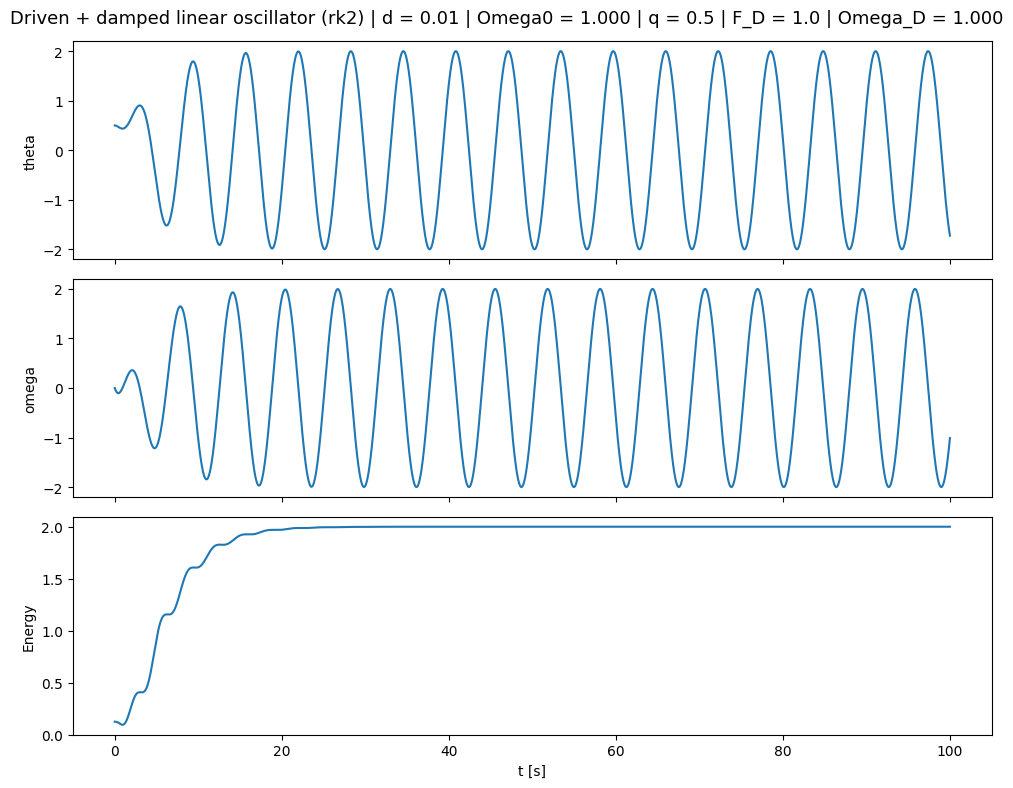

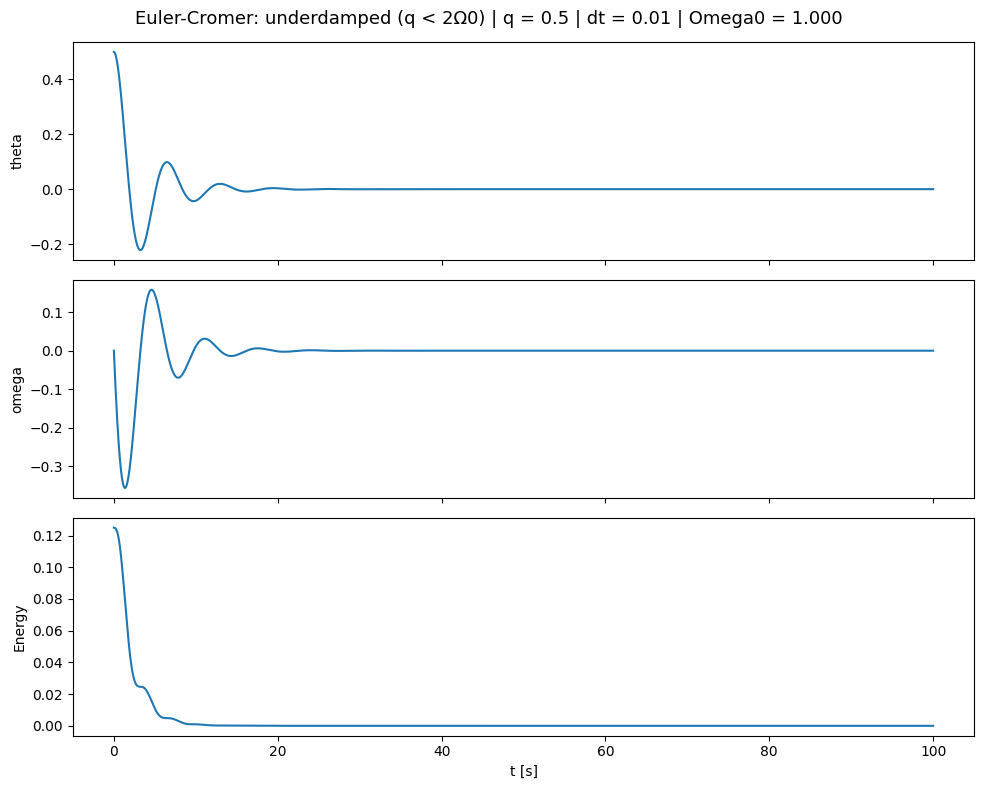

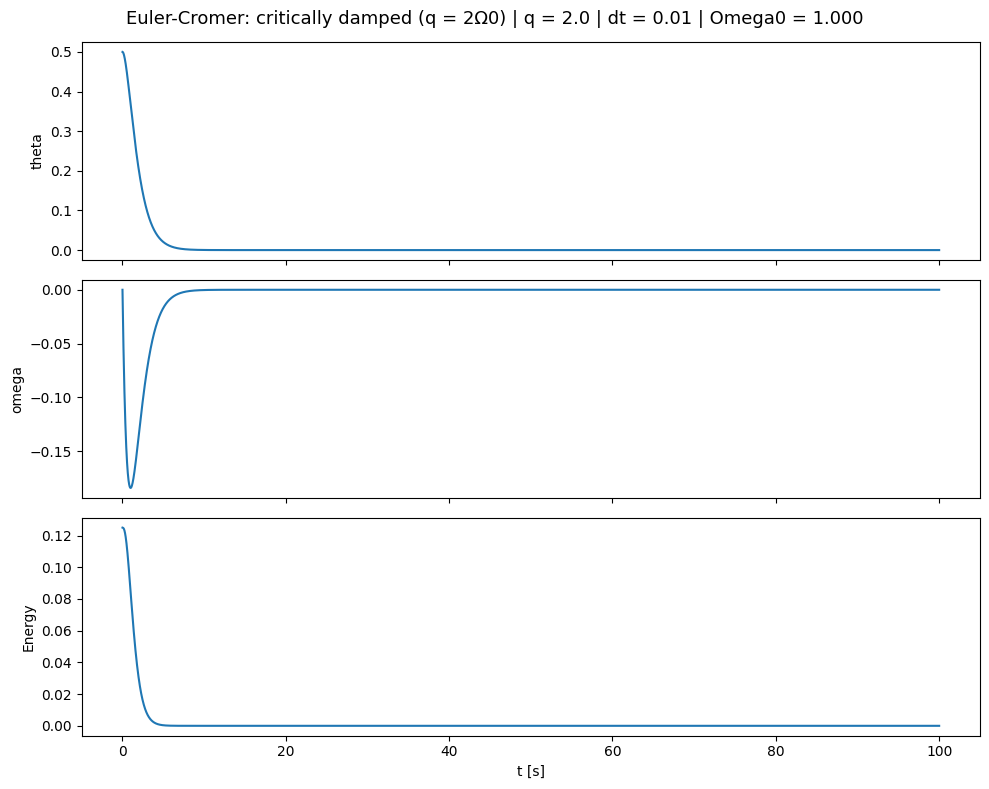

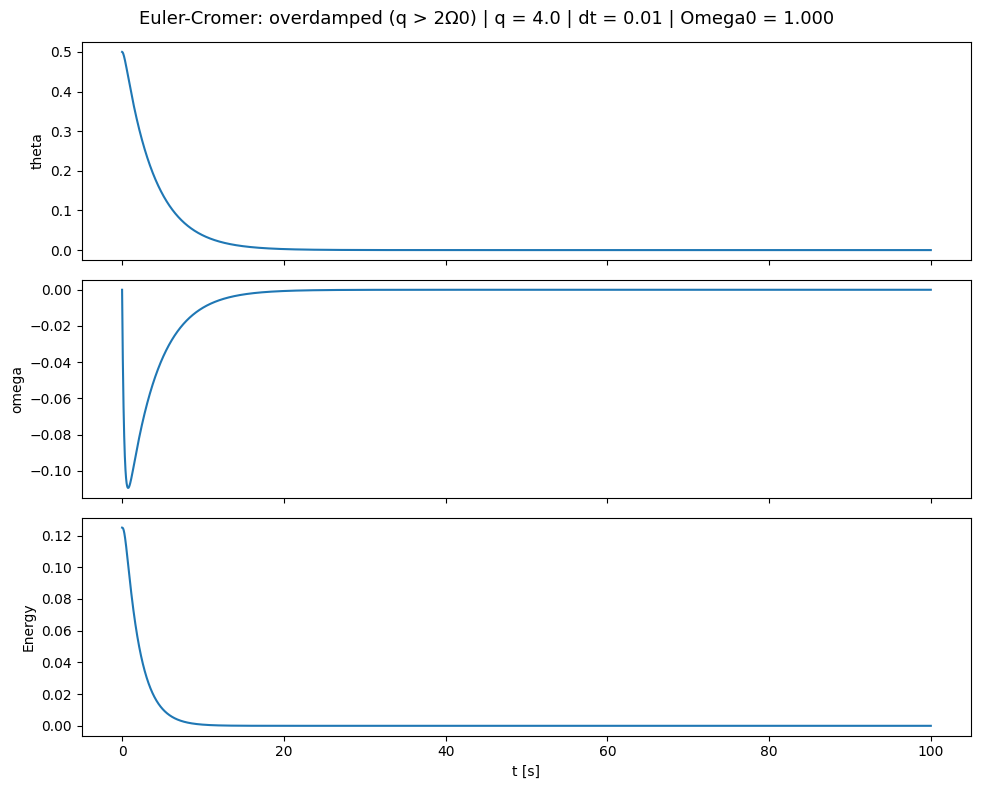

In [ ]:
# Lab 3, Task 2
# Linear oscillator (small-angle pendulum) WITH damping and driving
#
# Model:
#   dtheta/dt = omega
#   domega/dt = -Omega0^2 * theta - q * omega + F_D * sin(Omega_D * t)

import math;
import numpy as np;
import matplotlib.pyplot as plt;

# Helpers

def rhs(t, theta, omega, Omega0, q, F_D, Omega_D):
    # Returns (dtheta/dt, domega/dt)
    dtheta = omega;
    domega = -(Omega0**2) * theta - q * omega + F_D * np.sin(Omega_D * t);
    return dtheta, domega;

# Stepper/Iterator functions (explicit algorithms)

def step_euler(t, theta, omega, Omega0, q, F_D, Omega_D, dt):
    dth, dom = rhs(t, theta, omega, Omega0, q, F_D, Omega_D);
    return theta + dt * dth, omega + dt * dom;

def step_euler_cromer(t, theta, omega, Omega0, q, F_D, Omega_D, dt):
    # Updating omega first, then theta using new omega
    _, dom = rhs(t, theta, omega, Omega0, q, F_D, Omega_D);
    omega_new = omega + dt * dom;
    theta_new = theta + dt * omega_new;
    return theta_new, omega_new;

def step_rk2_midpoint(t, theta, omega, Omega0, q, F_D, Omega_D, dt):
    k1_th, k1_om = rhs(t, theta, omega, Omega0, q, F_D, Omega_D);
    th_mid = theta + 0.5 * dt * k1_th;
    om_mid = omega + 0.5 * dt * k1_om;
    k2_th, k2_om = rhs(t + 0.5 * dt, th_mid, om_mid, Omega0, q, F_D, Omega_D);
    return theta + dt * k2_th, omega + dt * k2_om;

# Simulator
def simulate(method, th0, om0, Omega0, q, F_D, Omega_D, dt, nsteps):
    theta = np.zeros(nsteps + 1);
    omega = np.zeros(nsteps + 1);
    tvals = np.arange(nsteps + 1) * dt;

    theta[0] = th0;
    omega[0] = om0;

    stepper = {"euler": step_euler, "euler_cromer": step_euler_cromer, "rk2": step_rk2_midpoint}[method];

    th, om, t = th0, om0, 0.0;
    for i in range(nsteps):
        th, om = stepper(t, th, om, Omega0, q, F_D, Omega_D, dt);
        t += dt;
        theta[i + 1] = th;
        omega[i + 1] = om;

    # Quadratic "oscillator energy" (not conserved when damping/driving present)
    E = 0.5 * (omega**2 + (Omega0**2) * theta**2);
    return tvals, theta, omega, E;

# Plotting
def plot_one_method_driven(method, th0, om0, Omega0, q, F_D, Omega_D, dt, nsteps):
    t, th, om, E = simulate(method, th0, om0, Omega0, q, F_D, Omega_D, dt, nsteps);

    fig, ax = plt.subplots(3, 1, figsize = (10, 8), sharex = True);
    fig.suptitle(f"Driven + damped linear oscillator ({method}) | d = {dt} | Omega0 = {Omega0:.3f} | q = {q} | F_D = {F_D} | Omega_D = {Omega_D:.3f}",
        fontsize = 13);

    ax[0].plot(t, th);
    ax[0].set_ylabel("theta");
    ax[1].plot(t, om);
    ax[1].set_ylabel("omega");
    ax[2].plot(t, E);
    ax[2].set_ylabel("Energy");
    ax[2].set_xlabel("t [s]");
    plt.tight_layout();
    plt.show();

def plot_ec_damping_case(label, th0, om0, Omega0, q, dt, nsteps):
    # No driving for damping-regime plots
    F_D = 0.0;
    Omega_D = Omega0;  # irrelevant since F_D = 0

    t, th, om, E = simulate("euler_cromer", th0, om0, Omega0, q, F_D, Omega_D, dt, nsteps);

    fig, ax = plt.subplots(3, 1, figsize = (10, 8), sharex = True);
    fig.suptitle(f"Euler-Cromer: {label} | q = {q} | dt = {dt} | Omega0 = {Omega0:.3f}", fontsize = 13);

    ax[0].plot(t, th);
    ax[0].set_ylabel("theta");
    ax[1].plot(t, om);
    ax[1].set_ylabel("omega");
    ax[2].plot(t, E);
    ax[2].set_ylabel("Energy");
    ax[2].set_xlabel("t [s]");
    plt.tight_layout();
    plt.show();

# Main
def main():
    # Required by prompt
    L = 9.8;
    g = 9.8;
    Omega0 = math.sqrt(g / L);  # should be 1.0
    print(f"Using L = {L} m, g = {g} m/s^2 => Omega0 = sqrt(g/L) = {Omega0:.6f} rad/s");

    dt = 0.01;
    tmax = 100.0;
    nsteps = int(tmax / dt);

    # Initial conditions
    th0 = 0.5;
    om0 = 0.0;
    # Driven + damped plots: one per method. Resonant choice: Omega_D = Omega0.
    q_drive = 0.5;
    F_D = 1.0;
    Omega_D = Omega0;

    for method in ["euler", "euler_cromer", "rk2"]:
        plot_one_method_driven(method, th0, om0, Omega0, q_drive, F_D, Omega_D, dt, nsteps);

    # Damping regimes (EC only, no driving) with Omega0=1, critical damping is q = 2*Omega0 = 2
    plot_ec_damping_case("underdamped (q < 2Ω0)", th0, om0, Omega0, q = 0.5, dt = dt, nsteps = nsteps);
    plot_ec_damping_case("critically damped (q = 2Ω0)", th0, om0, Omega0, q = 2.0, dt = dt, nsteps = nsteps);
    plot_ec_damping_case("overdamped (q > 2Ω0)", th0, om0, Omega0, q = 4.0, dt = dt, nsteps = nsteps);

if __name__ == "__main__":
    main()

#EOF





Omega0 = sqrt(g/L) = 1.000000 rad/s


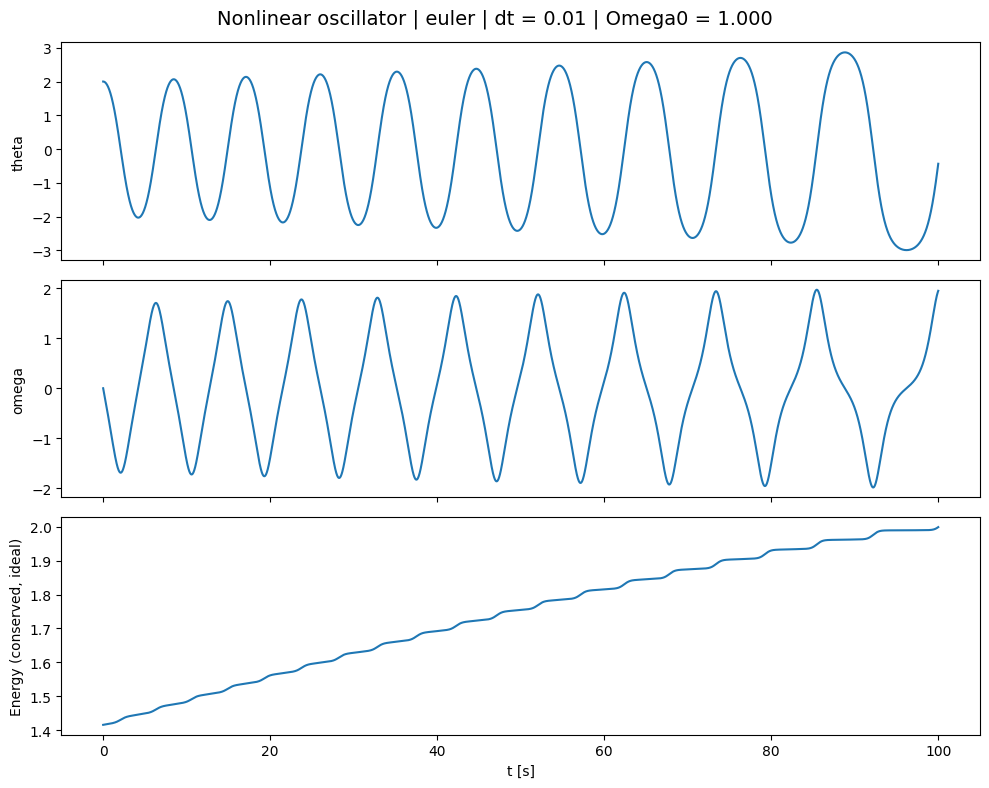

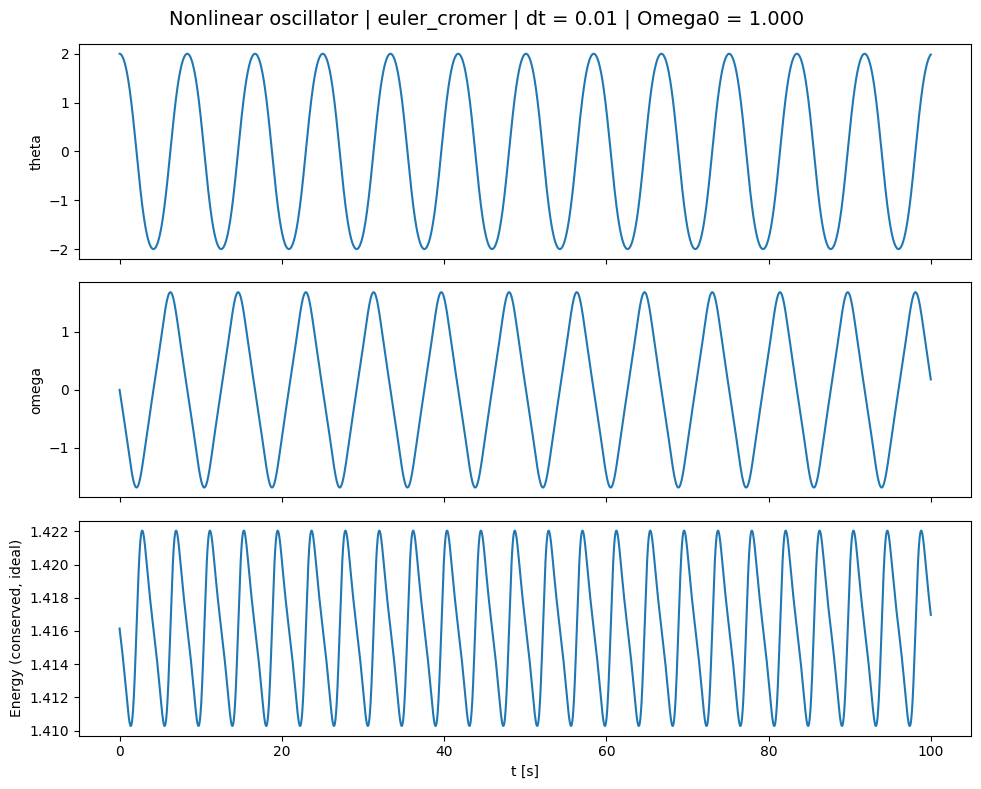

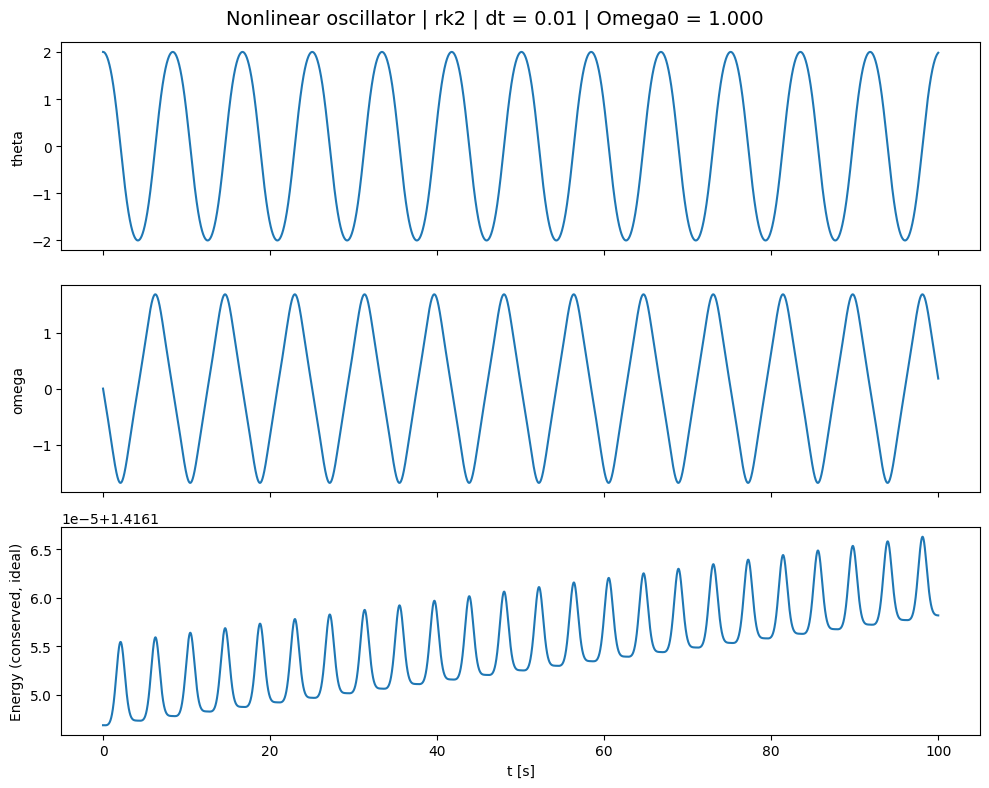

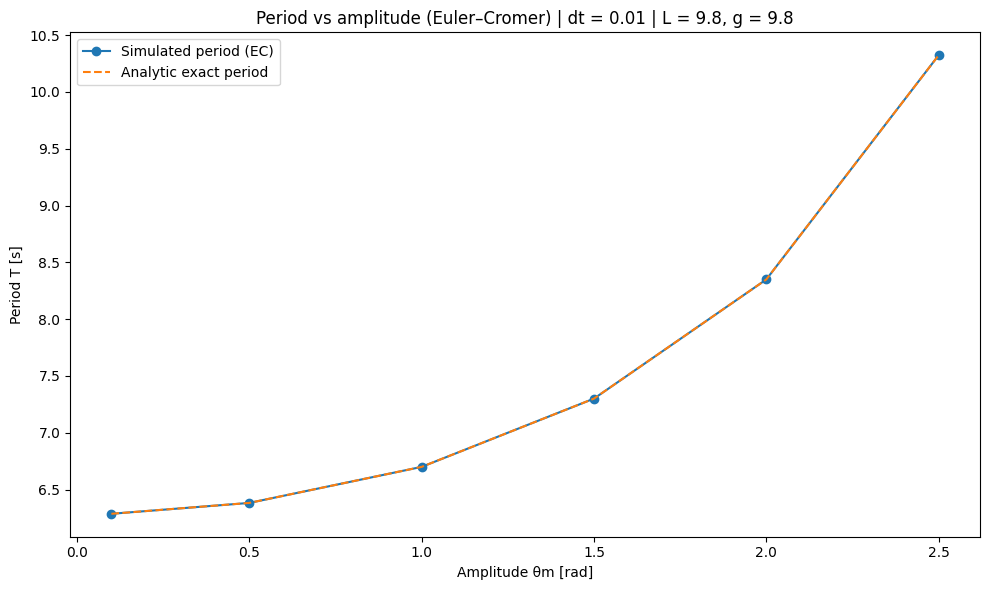

In [ ]:
# Lab 3, Task 3
# Nonlinear pendulum (full sin(theta)), no damping, no driving.
#
# ODE system:
#   dtheta/dt = omega
#   domega/dt = -(g/L) * sin(theta) = -Omega0^2 * sin(theta)

import math;
import numpy as np;
import matplotlib.pyplot as plt;

# Elliptic integral K(k) via AGM
def agm(a, b, tol = 1e-14, max_iter = 2000):
    for _ in range(max_iter):
        an = 0.5 * (a + b);
        bn = math.sqrt(a * b);
        if abs(an - bn) < tol * an:
            return an;
        a, b = an, bn;
    return a;

def K_complete_first_kind(k):
    k = abs(k);
    if k >= 1.0:
        return float("inf");
    A = agm(1.0, math.sqrt(1.0 - k * k));
    return math.pi / (2.0 * A);

# Just make RHS to prevent risk of double assigning dth and dom
def rhs(theta, omega, Omega0):
    dtheta = omega;
    domega = -(Omega0 ** 2) * math.sin(theta);
    return dtheta, domega;

# Steppers

def step_euler(theta, omega, Omega0, dt):
    dth, dom = rhs(theta, omega, Omega0);
    theta_new = theta + dt * dth;
    omega_new = omega + dt * dom;
    return theta_new, omega_new;

def step_euler_cromer(theta, omega, Omega0, dt):
    # omega_{n+1} uses acceleration at (theta_n, omega_n)
    _, dom = rhs(theta, omega, Omega0);
    omega_new = omega + dt * dom;
    theta_new = theta + dt * omega_new;
    return theta_new, omega_new;

def step_rk2_midpoint(theta, omega, Omega0, dt):
    k1_th, k1_om = rhs(theta, omega, Omega0);
    th_mid = theta + 0.5 * dt * k1_th;
    om_mid = omega + 0.5 * dt * k1_om;
    k2_th, k2_om = rhs(th_mid, om_mid, Omega0);
    theta_new = theta + dt * k2_th;
    omega_new = omega + dt * k2_om;
    return theta_new, omega_new;


# Simulation + period measurement
def simulate(method, theta0, omega0, Omega0, dt, tmax):
    nsteps = int(tmax / dt);
    t = np.linspace(0.0, nsteps * dt, nsteps + 1);

    theta = np.zeros(nsteps + 1);
    omega = np.zeros(nsteps + 1);
    theta[0] = theta0;
    omega[0] = omega0;

    stepper = {"euler": step_euler, "euler_cromer": step_euler_cromer, "rk2": step_rk2_midpoint}[method];

    th, om = theta0, omega0;
    for i in range(nsteps):
        th, om = stepper(th, om, Omega0, dt);
        theta[i + 1] = th;
        omega[i + 1] = om;

    # True conserved energy (scaled by m*L^2) for the undriven, undamped nonlinear pendulum ->
    # E = 1/2 * omega^2 + Omega0^2 * (1 - cos(theta))
    E = 0.5 * (omega ** 2) + (Omega0 ** 2) * (1.0 - np.cos(theta));
    return t, theta, omega, E;

def estimate_period_from_maxima(t, theta, omega):
    # Start at a maximum: theta(0)=theta_m, omega(0)=0. Next positive maximum occurs when omega crosses + -> - with theta > 0.
    for i in range(1, len(t)):
        if omega[i - 1] > 0.0 and omega[i] <= 0.0 and theta[i] > 0.0:
            w1, w2 = omega[i - 1], omega[i];
            t1, t2 = t[i - 1], t[i];
            if w2 != w1:
                frac = (0.0 - w1) / (w2 - w1);
                return t1 + frac * (t2 - t1);
            return t[i];
    return None;


# Plotting

def plot_method_simulation(method, theta0, omega0, Omega0, dt, tmax):
    t, th, om, E = simulate(method, theta0, omega0, Omega0, dt, tmax);

    fig, ax = plt.subplots(3, 1, figsize = (10, 8), sharex = True);
    fig.suptitle(f"Nonlinear oscillator | {method} | dt = {dt} | Omega0 = {Omega0:.3f}", fontsize = 14);

    ax[0].plot(t, th);
    ax[0].set_ylabel("theta");
    ax[1].plot(t, om);
    ax[1].set_ylabel("omega");
    ax[2].plot(t, E);
    ax[2].set_ylabel("Energy (conserved, ideal)");
    ax[2].set_xlabel("t [s]");
    plt.tight_layout();
    plt.show();

def plot_period_vs_amplitude_ec(amps, L, g, Omega0, dt):
    T_sim = [];
    T_an = [];

    for theta_m in amps:
        k = math.sin(theta_m / 2.0);
        Tex = 4.0 * math.sqrt(L / g) * K_complete_first_kind(k);
        tmax = 5.0 * Tex;  # long enough to capture at least the next maximum

        t, th, om, _ = simulate("euler_cromer", theta_m, 0.0, Omega0, dt, tmax);
        Tnum = estimate_period_from_maxima(t, th, om);

        # error handling
        T_sim.append(Tnum if Tnum is not None else float("nan"));
        T_an.append(Tex);

    T_sim = np.array(T_sim, dtype = float);
    T_an = np.array(T_an, dtype = float);

    plt.figure(figsize = (10, 6));
    plt.title(f"Period vs amplitude (Euler–Cromer) | dt = {dt} | L = {L}, g = {g}");
    plt.plot(amps, T_sim, "o-", label = "Simulated period (EC)");
    plt.plot(amps, T_an, "--", label = "Analytic exact period");
    plt.xlabel("Amplitude θm [rad]");
    plt.ylabel("Period T [s]");
    plt.legend();
    plt.tight_layout();
    plt.show();


# Main
def main():
    L = 9.8;
    g = 9.8;
    Omega0 = math.sqrt(g / L);  # should be 1.0
    print(f"Omega0 = sqrt(g/L) = {Omega0:.6f} rad/s");

    # dt based on what we decided in Task 1
    dt = 0.01;
    tmax = 100.0;

    # Initial condition for the 3 method plots
    theta0 = 2.0;   # radians
    omega0 = 0.0;

    # 3) Three plots: nonlinear oscillator simulation for each method
    for method in ["euler", "euler_cromer", "rk2"]:
        plot_method_simulation(method, theta0, omega0, Omega0, dt, tmax);

    # 3) Period vs amplitude (EC only) + analytic comparison
    amps = np.array([0.1, 0.5, 1.0, 1.5, 2.0, 2.5]);  # rad
    plot_period_vs_amplitude_ec(amps, L, g, Omega0, dt);

if __name__ == "__main__":
    main();

# EOF

